In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
analysis = pd.read_csv("water_quality_of_river_yamuna-2014.csv",encoding="latin1")
print(analysis.columns.tolist)
analysis.columns = ['station_code','location','state',
    'temperature_min','temperature_max','temperature_avg',
    'do_min','do_max','do_avg',
    'ph_min','ph_max','ph_avg',
    'conductivity_min','conductivity_max','conductivity_avg',
    'bod_min','bod_max','bod_avg',
    'nitrate_min','nitrate_max','nitrate_avg',
    'fecal_coliform_min','fecal_coliform_max','fecal_coliform_avg',
    'total_coliform_min','total_coliform_max','total_coliform_avg']
print(analysis.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['STATION CODE', 'LOCATIONS', 'STATE', 'TEMPERATURE ºC  : Min',
       'TEMPERATURE ºC  : Max', 'TEMPERATURE ºC  : Mean',
       'D.O. (mg/l)  : Min  : > 4 mg/l', 'D.O. (mg/l)  : Max  : > 4 mg/l',
       'D.O. (mg/l)  : Mean  : > 4 mg/l', 'pH  : Min  : 6.5-8.5',
       'pH  : Max  : 6.5-8.5', 'pH  : Mean  : 6.5-8.5',
       'CONDUCTIVITY (µmhos/cm)  : Min', 'CONDUCTIVITY (µmhos/cm)  : Max',
       'CONDUCTIVITY (µmhos/cm)  : Mean', 'B.O.D. (mg/l)  : Min  : < 3 mg/l',
       'B.O.D. (mg/l)  : Max  : < 3 mg/l', 'B.O.D. (mg/l)  : Mean  : < 3 mg/l',
       'NITRATE- N+ NITRITE-N (mg/l)  : Min',
       'NITRATE- N+ NITRITE-N (mg/l)  : Max',
       'NITRATE- N+ NITRITE-N (mg/l)  : Mean',
       'FECAL COLIFORM (MPN/100ml)  : Min  : < 2500 MPN/100ml',
       'FECAL COLIFORM (MPN/100ml)  : Max  : < 2500 MPN/100ml',
       'FECAL COLIFORM (MPN/100ml)  : Mean  : < 2500 MPN/100ml',
       'TOTAL COLIFORM (MPN/100ml)  : Min  : < 5000 MPN/100ml',
       '

In [3]:
# print(analysis.isna().sum())
analysis.shape
print(repr(analysis["state"].unique().tolist()))

['UTTARAKHAND', 'HIMACHAL PRADESH', 'DELHI', 'UTTAR PRADESH', 'CPCB, DELHI']


In [4]:
analysis[analysis['conductivity_min'].isna()][['location','state']]

,location,state
0,"YAMUNA AT U/S OF LAKHWAR DAM, U.P",UTTARAKHAND
1,"YAMUNA AT U/S DAK PATTHAR, UTTAR PARDESH",UTTARAKHAND
4,"YAMUNA AT WAZIRABAD, DELHI, CPCB",DELHI
5,"YAMUNA AT NIZAMUDDIN, DELHI",DELHI
6,"YAMUNA AT OKHLA BRIDGE (INLET OF AGRA CANAL), ...",DELHI
8,"YAMUNA AT MATHURA U/S , U.P.",DELHI
10,"YAMUNA AT MATHURA D/S , U.P.",DELHI
11,"YAMUNA AT AGRA U/S, U.P.",UTTAR PRADESH
12,"YAMUNA AT D/S OF AGRA, U.P.",UTTAR PRADESH
14,"YAMUNA AT BATESWAR, U.P","CPCB, DELHI"


In [5]:
analysis.describe(include="all")

,station_code,location,state,temperature_min,temperature_max,temperature_avg,do_min,do_max,do_avg,ph_min,...,bod_avg,nitrate_min,nitrate_max,nitrate_avg,fecal_coliform_min,fecal_coliform_max,fecal_coliform_avg,total_coliform_min,total_coliform_max,total_coliform_avg
count,19.000000,19,19,8.000000,8.000000,8.000000,12.000000,12.000000,12.00000,12.000000,...,12.000000,17.000000,17.000000,17.000000,15.000000,15.000000,15.00000,19.000000,1.900000e+01,1.900000e+01
unique,NaN,19,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"YAMUNA AT U/S OF LAKHWAR DAM, U.P",DELHI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1510.105263,NaN,NaN,16.225000,28.175000,23.062500,3.783333,6.900000,5.25000,7.266667,...,8.925000,0.222353,2.151765,1.200000,20067.666667,65888.466667,40827.00000,86615.894737,1.977838e+07,2.921154e+06
std,486.366448,NaN,NaN,2.071404,5.172938,2.587297,2.750482,2.923572,2.91906,0.551582,...,10.950892,0.467968,5.505616,3.004996,37706.149017,138714.871945,77297.99861,139079.995407,5.092722e+07,7.050974e+06
min,1069.000000,NaN,NaN,14.000000,21.000000,18.700000,0.300000,2.800000,1.20000,6.400000,...,1.100000,0.000000,0.000000,0.000000,7.000000,11.000000,9.00000,17.000000,2.100000e+01,1.900000e+01
25%,1124.500000,NaN,NaN,14.750000,25.050000,21.650000,1.325000,5.550000,3.12500,7.000000,...,1.450000,0.000000,0.000000,0.000000,1650.000000,2250.000000,2250.00000,2900.000000,1.200000e+04,6.754500e+03
50%,1490.000000,NaN,NaN,16.000000,28.500000,24.250000,3.700000,7.400000,5.50000,7.150000,...,4.700000,0.000000,0.000000,0.000000,4900.000000,7900.000000,4900.00000,33000.000000,3.500000e+04,3.300000e+04
75%,1553.500000,NaN,NaN,17.250000,33.000000,25.000000,6.400000,8.400000,7.70000,7.550000,...,11.200000,0.100000,0.600000,0.200000,23500.000000,74000.000000,39182.00000,60000.000000,2.100000e+05,1.786365e+05


In [6]:
print((analysis['do_min'] > analysis['do_max']).sum())
print((analysis['temperature_min'] > analysis['temperature_max']).sum())
print((analysis['bod_min'] > analysis['bod_max']).sum())

0
0
0


In [7]:
print(analysis[["do_avg","bod_avg"]].dropna().corr())
print("n =", analysis[["do_avg","bod_avg"]].dropna().shape[0])

           do_avg   bod_avg
do_avg   1.000000 -0.812745
bod_avg -0.812745  1.000000
n = 12


clarifies inverse DO/BOD relationship 

In [8]:
print(analysis[["fecal_coliform_avg","total_coliform_avg"]].dropna().corr())
print("n =", analysis[["fecal_coliform_avg","total_coliform_avg"]].dropna().shape[0])

                    fecal_coliform_avg  total_coliform_avg
fecal_coliform_avg            1.000000            0.997269
total_coliform_avg            0.997269            1.000000
n = 15


TAUTOLOGY

In [9]:
print(analysis[["ph_avg","fecal_coliform_avg"]].dropna().corr())
print("n =", analysis[["ph_avg","fecal_coliform_avg"]].dropna().shape[0])

                      ph_avg  fecal_coliform_avg
ph_avg              1.000000           -0.581099
fecal_coliform_avg -0.581099            1.000000
n = 8


weak evidence, n=8

In [10]:
print(analysis[["nitrate_avg","total_coliform_avg"]].dropna().corr())
print(analysis[['nitrate_avg','total_coliform_avg']].dropna().drop([5,6]).corr())
print("n =", analysis[["nitrate_avg","total_coliform_avg"]].dropna().shape[0])

                    nitrate_avg  total_coliform_avg
nitrate_avg            1.000000            0.936547
total_coliform_avg     0.936547            1.000000
                    nitrate_avg  total_coliform_avg
nitrate_avg            1.000000           -0.177335
total_coliform_avg    -0.177335            1.000000
n = 17


In [11]:
analysis[['nitrate_avg','total_coliform_avg',"location"]].dropna().sort_values('nitrate_avg', ascending=False)

,nitrate_avg,total_coliform_avg,location
6,9.2,23816667,"YAMUNA AT OKHLA BRIDGE (INLET OF AGRA CANAL), ..."
5,9.0,12010833,"YAMUNA AT NIZAMUDDIN, DELHI"
17,1.8,5975,"YAMUNA AT ALLAHABAD D/S (BALUA GHAT), U.P"
2,0.2,19,"YAMUNA , U/S PAONTA SAHIB, H.P"
3,0.2,21,"YAMUNA , D/S PAONTA SAHIB, H.P"
0,0.0,35000,"YAMUNA AT U/S OF LAKHWAR DAM, U.P"
1,0.0,6509,"YAMUNA AT U/S DAK PATTHAR, UTTAR PARDESH"
8,0.0,33000,"YAMUNA AT MATHURA U/S , U.P."
7,0.0,73727,"YAMUNA AT KESIGHAT, VRINDAVAN"
9,0.0,117273,"YAMUNA AT VISHRAMGHAT, MATHURA"


two severely contaminated stations (YAMUNA AT OKHLA BRIDGE (INLET OF AGRA CANAL), DELHI and YAMUNA AT NIZAMUDDIN, DELHI ) drive an apparent nitrate-coliform correlation; this does not hold across the remaining 15 stations.

In [12]:
analysis

,station_code,location,state,temperature_min,temperature_max,temperature_avg,do_min,do_max,do_avg,ph_min,...,bod_avg,nitrate_min,nitrate_max,nitrate_avg,fecal_coliform_min,fecal_coliform_max,fecal_coliform_avg,total_coliform_min,total_coliform_max,total_coliform_avg
0,1494,"YAMUNA AT U/S OF LAKHWAR DAM, U.P",UTTARAKHAND,18.0,21.0,19.7,4.2,8.4,6.5,8.0,...,1.1,0.00,0.00,0.0,7900.0,7900.0,7900.0,35000,35000,35000
1,1490,"YAMUNA AT U/S DAK PATTHAR, UTTAR PARDESH",UTTARAKHAND,17.0,21.0,18.7,6.6,8.4,7.7,8.1,...,1.3,0.00,0.00,0.0,1100.0,1100.0,1100.0,17,13000,6509
2,1553,"YAMUNA , U/S PAONTA SAHIB, H.P",HIMACHAL PRADESH,15.0,28.0,22.3,6.4,8.4,7.7,6.4,...,1.2,0.10,0.60,0.2,7.0,11.0,9.0,18,21,19
3,1554,"YAMUNA , D/S PAONTA SAHIB, H.P",HIMACHAL PRADESH,17.0,29.0,23.7,5.8,8.2,7.5,6.6,...,1.5,0.10,0.60,0.2,8.0,16.0,11.0,17,24,21
4,1120,"YAMUNA AT WAZIRABAD, DELHI, CPCB",DELHI,NaN,NaN,NaN,6.4,12.8,9.3,7.2,...,2.4,NaN,NaN,NaN,NaN,NaN,NaN,450,43000,10003
5,1121,"YAMUNA AT NIZAMUDDIN, DELHI",DELHI,NaN,NaN,NaN,0.3,2.8,1.2,7.1,...,17.2,1.10,17.50,9.0,NaN,NaN,NaN,330000,54000000,12010833
6,1375,"YAMUNA AT OKHLA BRIDGE (INLET OF AGRA CANAL), ...",DELHI,NaN,NaN,NaN,0.4,3.0,1.4,7.1,...,17.3,1.10,15.90,9.2,NaN,NaN,NaN,450000,160000000,23816667
7,2495,"YAMUNA AT KESIGHAT, VRINDAVAN",UTTAR PRADESH,14.0,34.0,25.0,2.0,6.5,4.0,7.4,...,8.3,0.00,0.00,0.0,31000.0,93000.0,43546.0,63000,90000,73727
8,1123,"YAMUNA AT MATHURA U/S , U.P.",DELHI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.00,0.00,0.0,23000.0,23000.0,23000.0,33000,33000,33000
9,2494,"YAMUNA AT VISHRAMGHAT, MATHURA",UTTAR PRADESH,15.0,33.0,25.0,1.5,6.4,3.7,7.2,...,9.2,0.00,0.00,0.0,28000.0,78000.0,53546.0,57000,180000,117273


In [13]:
# state_order = ["UTTARAKHAND", "HIMACHAL PRADESH", "HARYANA", "DELHI", "UTTAR PRADESH"]
# analysis["state"] = analysis["state"].str.strip().str.upper()
# analysis["state"] = pd.Categorical(analysis["state"],categories = state_order,ordered = True)
# analysis = analysis.sort_values("state")
# analysis
analysis['location'] = analysis['location'].astype(str).str.strip()

analysis['state'] = (analysis['state']
    .str.strip()
    .str.upper()
    .str.replace(r'^CPCB,\s*', '', regex=True))

state_order = ["UTTARAKHAND", "HIMACHAL PRADESH", "HARYANA", "DELHI", "UTTAR PRADESH"]
analysis['state'] = pd.Categorical(analysis['state'], categories=state_order, ordered=True)

analysis_sorted = analysis.sort_values('state')
print(analysis_sorted['state'].isna().sum())
analysis_sorted[['location','state']]

0


,location,state
0,"YAMUNA AT U/S OF LAKHWAR DAM, U.P",UTTARAKHAND
1,"YAMUNA AT U/S DAK PATTHAR, UTTAR PARDESH",UTTARAKHAND
2,"YAMUNA , U/S PAONTA SAHIB, H.P",HIMACHAL PRADESH
3,"YAMUNA , D/S PAONTA SAHIB, H.P",HIMACHAL PRADESH
16,"YAMUNA AT JUHIKA B/C WITH CHANBAL, ETAWAH, U.P",DELHI
15,"YAMUNA AT ETAWAH, U.P.",DELHI
14,"YAMUNA AT BATESWAR, U.P",DELHI
10,"YAMUNA AT MATHURA D/S , U.P.",DELHI
18,YAMUNA AT OKHLA AFTER MEETING OF SHAHDARA DRAI...,DELHI
6,"YAMUNA AT OKHLA BRIDGE (INLET OF AGRA CANAL), ...",DELHI


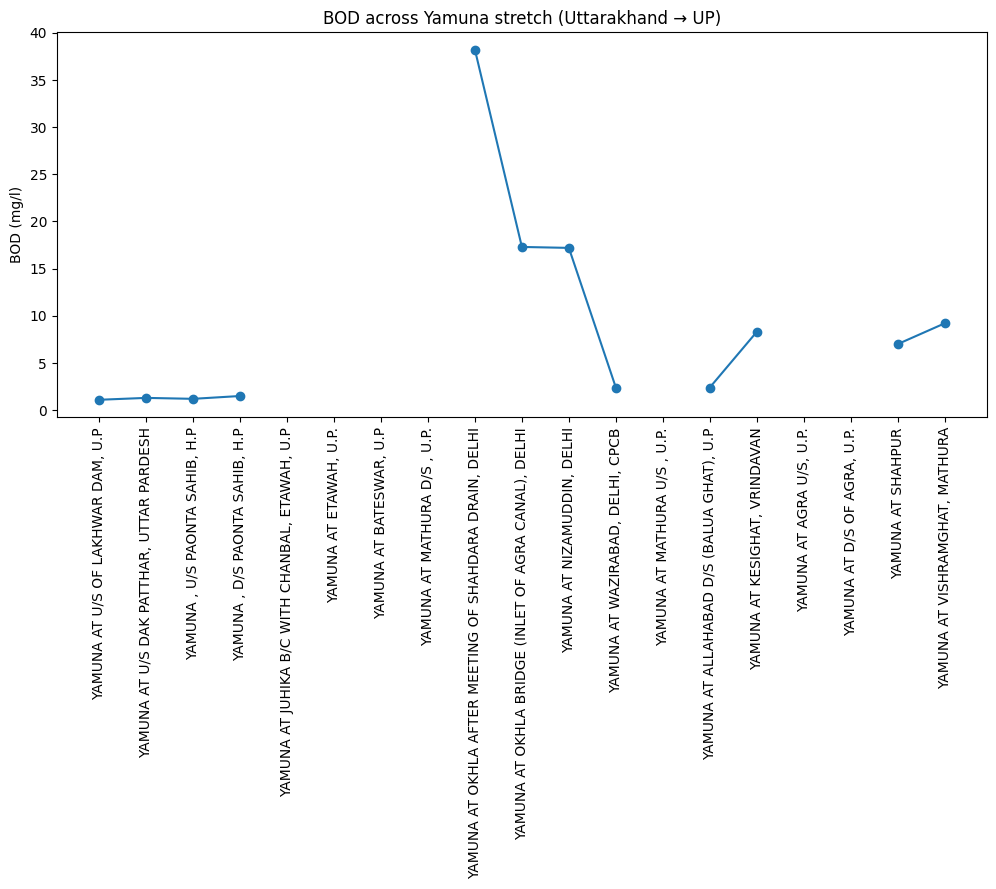

In [14]:
plt.figure(figsize=(12,5))
plt.plot(analysis_sorted['location'], analysis_sorted['bod_avg'], marker = 'o')
plt.xticks(rotation=90)
plt.ylabel('BOD (mg/l)')
plt.title('BOD across Yamuna stretch (Uttarakhand → UP)')
# plt.tight_layout()
plt.show()

In [15]:
missing_stations = analysis_sorted[analysis_sorted['bod_avg'].isna()]['location'].tolist()
print("No BOD data for:", missing_stations)

No BOD data for: ['YAMUNA AT JUHIKA B/C WITH CHANBAL, ETAWAH, U.P', 'YAMUNA AT ETAWAH, U.P.', 'YAMUNA AT BATESWAR, U.P', 'YAMUNA AT MATHURA D/S , U.P.', 'YAMUNA AT MATHURA U/S , U.P.', 'YAMUNA AT AGRA U/S, U.P.', 'YAMUNA AT D/S OF AGRA, U.P.']


/tmp/ipykernel_48369/2323342870.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


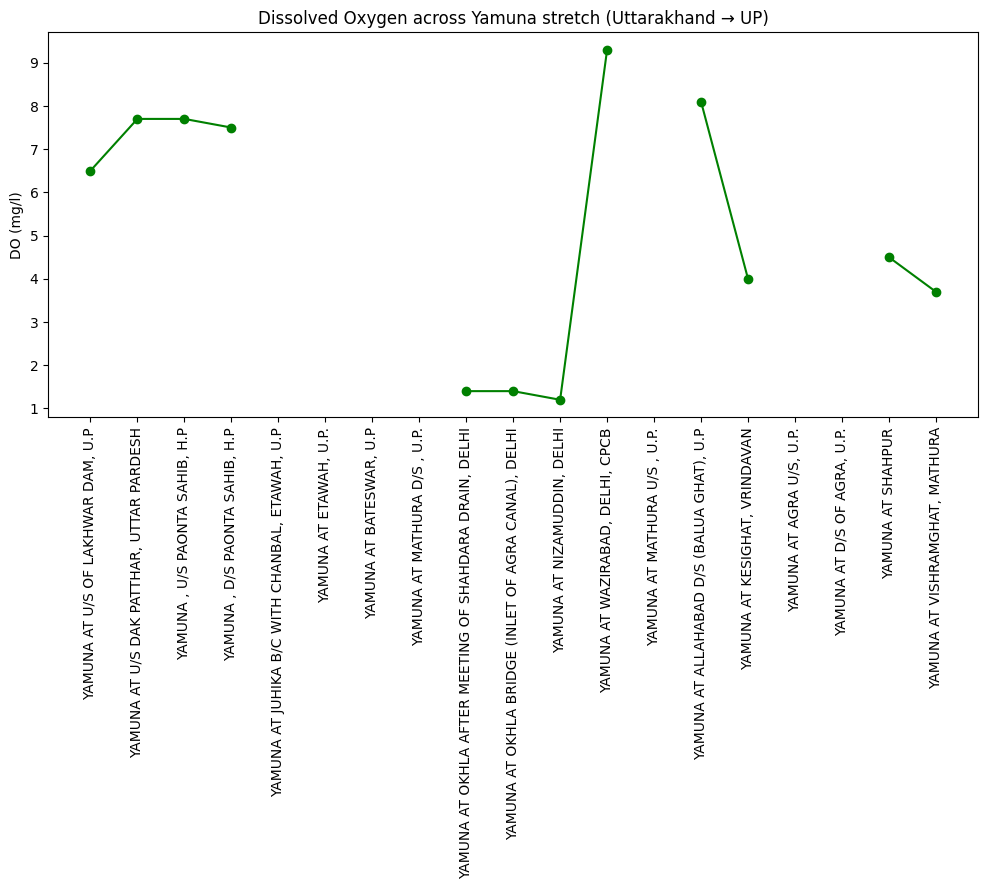

No DO data for: ['YAMUNA AT JUHIKA B/C WITH CHANBAL, ETAWAH, U.P', 'YAMUNA AT ETAWAH, U.P.', 'YAMUNA AT BATESWAR, U.P', 'YAMUNA AT MATHURA D/S , U.P.', 'YAMUNA AT MATHURA U/S , U.P.', 'YAMUNA AT AGRA U/S, U.P.', 'YAMUNA AT D/S OF AGRA, U.P.']


In [16]:
plt.figure(figsize=(12,5))
plt.plot(analysis_sorted['location'], analysis_sorted['do_avg'], marker='o', color='green')
plt.xticks(rotation=90)
plt.ylabel('DO (mg/l)')
plt.title('Dissolved Oxygen across Yamuna stretch (Uttarakhand → UP)')
plt.tight_layout()
plt.show()

missing_do = analysis_sorted[analysis_sorted['do_avg'].isna()]['location'].tolist()
print("No DO data for:", missing_do)

/tmp/ipykernel_48369/2852383285.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


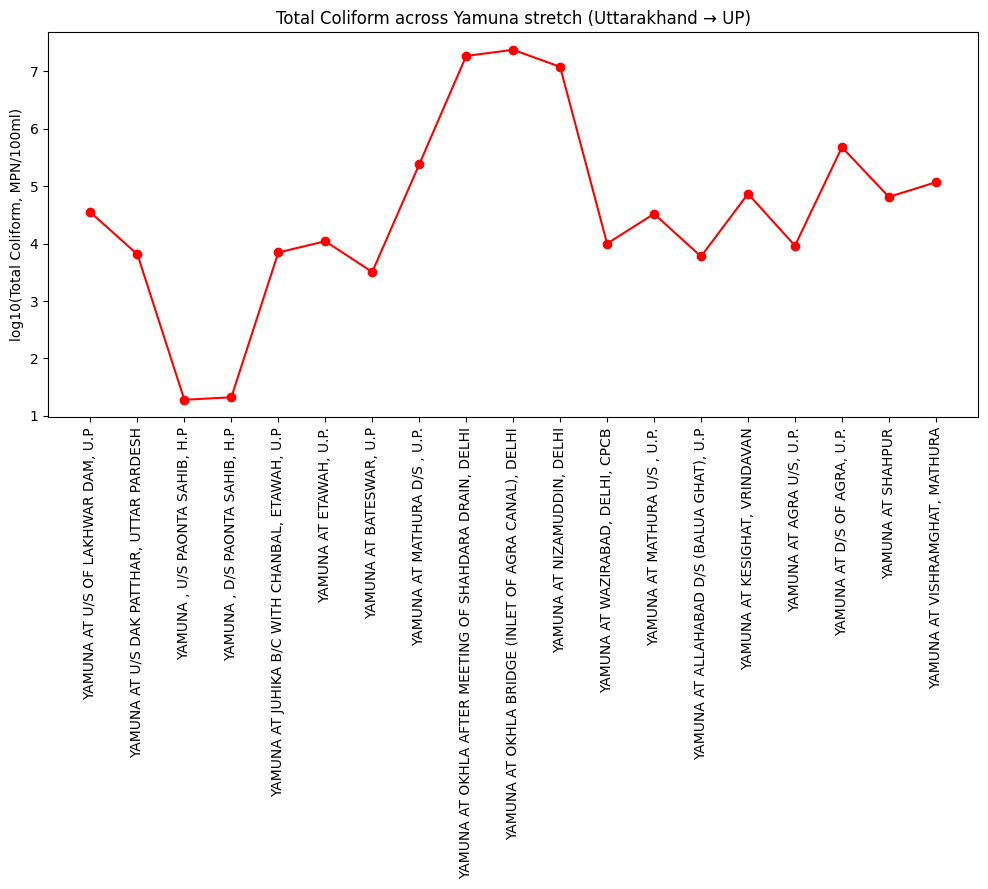

In [17]:
plt.figure(figsize=(12,5))
plt.plot(analysis_sorted['location'], np.log10(analysis_sorted['total_coliform_avg'].replace(0, np.nan)), marker='o', color='red')
plt.xticks(rotation=90)
plt.ylabel('log10(Total Coliform, MPN/100ml)')
plt.title('Total Coliform across Yamuna stretch (Uttarakhand → UP)')
plt.tight_layout()
plt.show()

In [18]:
bod_violations = (analysis_sorted['bod_avg'] > 3).sum() # CPCB bathing standard: BOD should be <3mg/l
do_violations = (analysis_sorted['do_avg'] < 5).sum()      # CPCB standard: DO should be >5mg/l
coliform_violation = (analysis_sorted["total_coliform_avg"]>5000).sum()
total = analysis_sorted['bod_avg'].notna().sum(), analysis_sorted['do_avg'].notna().sum(),analysis_sorted["total_coliform_avg"].notna().sum()
print(f"BOD violations: {bod_violations}/{total[0]} stations")
print(analysis_sorted[analysis_sorted["bod_avg"]>3][["bod_avg","location","state"]])
print(f"DO violations: {do_violations}/{total[1]} stations")
print(analysis_sorted[analysis_sorted["do_avg"]<5][["do_avg","location","state"]])
print(f"COLIFORM voilations: {coliform_violation}/{total[2]} stations")
print(analysis_sorted[analysis_sorted["total_coliform_avg"]>5000][["total_coliform_avg","location","state"]].sort_values("total_coliform_avg",ascending=False))

BOD violations: 6/12 stations
    bod_avg                                           location          state
18     38.2  YAMUNA AT OKHLA AFTER MEETING OF SHAHDARA DRAI...          DELHI
6      17.3  YAMUNA AT OKHLA BRIDGE (INLET OF AGRA CANAL), ...          DELHI
5      17.2                        YAMUNA AT NIZAMUDDIN, DELHI          DELHI
7       8.3                      YAMUNA AT KESIGHAT, VRINDAVAN  UTTAR PRADESH
13      7.0                                  YAMUNA AT SHAHPUR  UTTAR PRADESH
9       9.2                     YAMUNA AT VISHRAMGHAT, MATHURA  UTTAR PRADESH
DO violations: 6/12 stations
    do_avg                                           location          state
18     1.4  YAMUNA AT OKHLA AFTER MEETING OF SHAHDARA DRAI...          DELHI
6      1.4  YAMUNA AT OKHLA BRIDGE (INLET OF AGRA CANAL), ...          DELHI
5      1.2                        YAMUNA AT NIZAMUDDIN, DELHI          DELHI
7      4.0                      YAMUNA AT KESIGHAT, VRINDAVAN  UTTAR PRADESH
13     4.5

**CONCLUSIONS**

> BOD exceeded the CPCB bathing-water threshold (>3mg/l) at 6/12 stations with valid data (63%)

> DO fell below the safe threshold (<5mg/l) at 6/12 stations with valid data (63%)

> COLIFORM exceeded the CLASS C threshold (>5000MPN/100ml) at 16/19 stations with valid data (100%)

> Yamuna at OKHLA Bridge and Nizamuddin , Delhi show the most severe pollution across 

**LIMITATIONS**

> n=19 stations total, single year(2014) snapshot , no true time trend exists in this data.

> per parameter coverage is inconsistent , temperature(8/19),BOD/DO~12/19 , coliform 19/19

> The Nitrate-Colifrom (r=0.94) correlation is driven entirely by 2 of 17 stations and does not hold across the rest 